# PyTorch : Paper Replicating

(Date - 25/June/2026)

## 0. Getting setup (imports)

In [1]:
import torch
import torchvision
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from helper_functions import set_seeds, download_data, plot_loss_curves
from going_modular import data_setup, engine
import matplotlib.pyplot as plt
from torchvision import transforms
from torch import nn
from torchinfo import summary
import random

device = "cuda" if torch.cuda.is_available() else "cpu"
device

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cpu'

## 1. Getting data ready

In [2]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] data\pizza_steak_sushi directory exists, skipping download.


WindowsPath('data/pizza_steak_sushi')

In [3]:
train_dir = str(image_path / "train")
test_dir = str(image_path / "test")

## 2. Creating datasets and dataloaders

### 2.1 Creating a tranform manually

In [4]:
IMG_SIZE = 224

manual_transform = transforms.Compose([
    transforms.Resize(size=(IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

print(f"Manually created transform: {manual_transform}")

Manually created transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


### 2.2 Setting up dataloaders

In [5]:
BATCH_SIZE = 32

train_dataloader, test_datloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    train_transform=manual_transform,
    test_transform=None,
    batch_size=BATCH_SIZE
)

train_dataloader, test_datloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x1dd24d66d90>,
 ['pizza', 'steak', 'sushi'])

### 2.3 Visualizing a single image

In [6]:
image_batch, label_batch = next(iter(train_dataloader))
image, label = image_batch[0], label_batch[0]
image.shape, label

(torch.Size([3, 224, 224]), tensor(1))

Text(0.5, 1.0, 'Label: steak\nImage shape: torch.Size([3, 224, 224])')

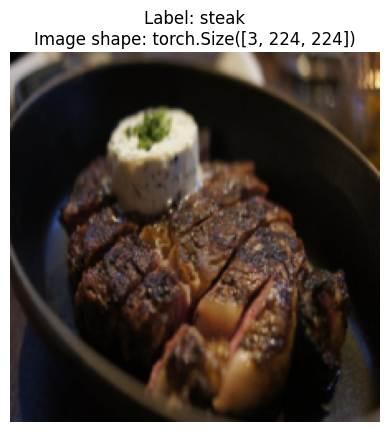

In [7]:
plt.imshow(image.permute(1,2,0))
plt.axis("off")
plt.title(f"Label: {class_names[label]}\nImage shape: {image.shape}")

## 3. Replicating the ViT (Vision Transformer) paper: an Overview

You may get an amazing overview from [here.](https://www.learnpytorch.io/08_pytorch_paper_replicating/#3-replicating-the-vit-paper-an-overview)


## 4. Equation 1: Split data into patches and creating the class, position and patch embedding

(Date - 3/July/2026)


### 4.1 Calculating patch embedding input and output shapes by hand

In [8]:
height = 224
width = 224
color_channels = 3
patch_size = 16

number_of_patches = int((height*width)/patch_size**2)
print(f"Number of patches (N) with:\nheight = {height} | width = {width} | patch_size = {patch_size}\nis {number_of_patches}")

Number of patches (N) with:
height = 224 | width = 224 | patch_size = 16
is 196


In [9]:
embedding_layer_input_shape = (height, width, color_channels)
embedding_layer_output_shape = {number_of_patches, patch_size**2 * color_channels}

print(f"embedding_layer_input_shape (single 2D image) : {embedding_layer_input_shape}")
print(f"embedding_layer_output_shape (single 2D image flatten into patches) : {embedding_layer_output_shape}")

embedding_layer_input_shape (single 2D image) : (224, 224, 3)
embedding_layer_output_shape (single 2D image flatten into patches) : {768, 196}


### 4.2 Turning a single image into patches

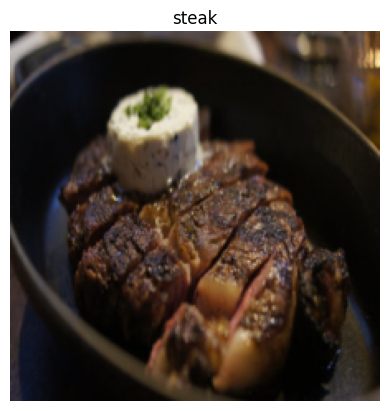

In [10]:
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis("off");

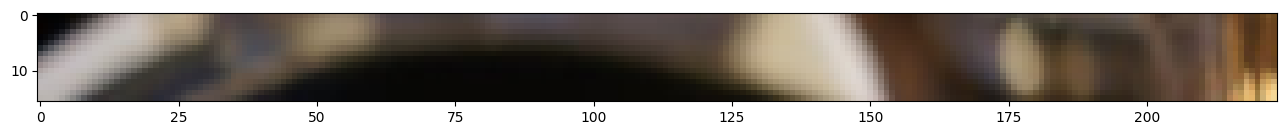

In [11]:
permuted_image = image.permute(1,2,0)

plt.figure(figsize=(patch_size, patch_size))
plt.imshow(permuted_image[:patch_size, :, :]);

Number of patches per row: 14.0
Patch size: 16 pixels x 16 pixels


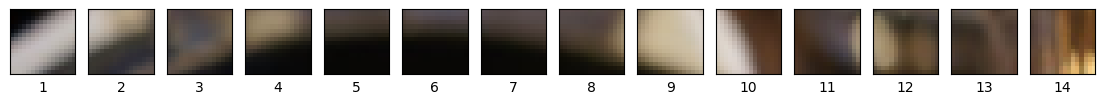

In [12]:
img_size = 224
patch_size = 16
num_patches = img_size/patch_size

assert img_size % patch_size == 0, "Image size must be divisible by the patch size."
print(f"Number of patches per row: {num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

fig, axs = plt.subplots(nrows=1,
                       ncols=img_size//patch_size,
                       figsize=(num_patches, num_patches),
                       sharex=True,
                       sharey=True)

for i, patch in enumerate(range(0, img_size, patch_size)):
    axs[i].imshow(permuted_image[:patch_size, patch:patch+patch_size, :]); # This prints the first row
    # axs[i].imshow(permuted_image[patch:patch+patch_size, :patch_size, :]) # This prints the first column
    axs[i].set_xlabel(i+1) 
    axs[i].set_xticks([])
    axs[i].set_yticks([])

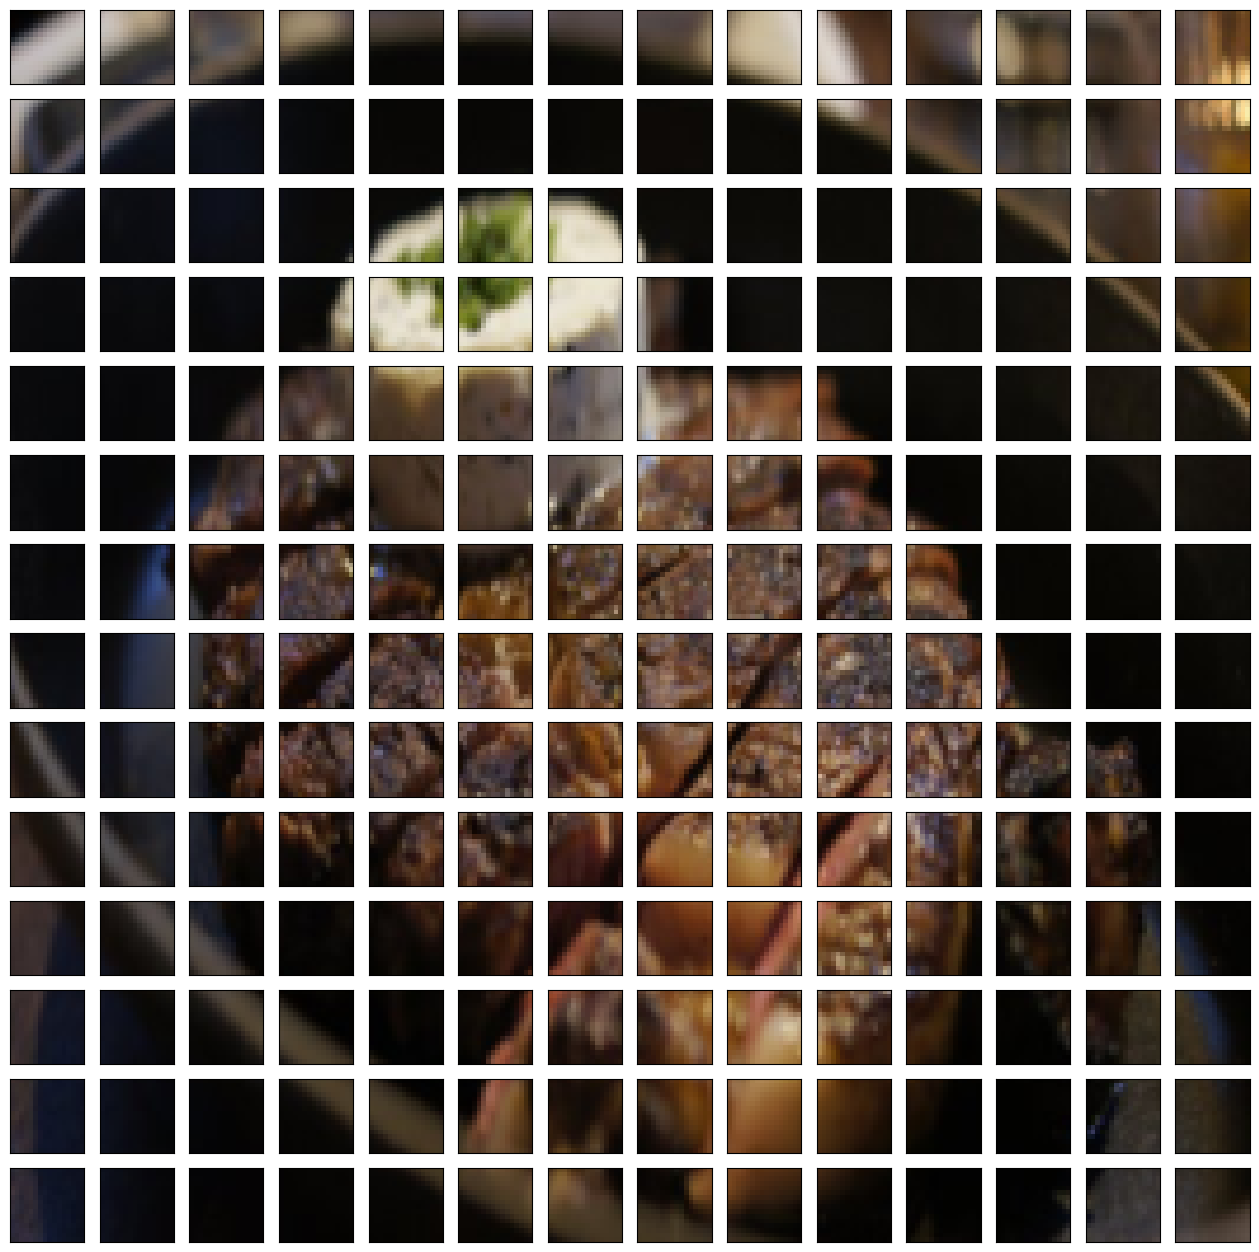

In [13]:
fig, axis = plt.subplots(nrows=img_size//patch_size,
                         ncols=img_size//patch_size,
                         figsize=(patch_size, patch_size),
                         sharex=True,
                         sharey=True)

k = 0
for j in range(14):
    for i, patch in enumerate(range(0, img_size, patch_size)):
        axis[j, i].imshow(permuted_image[k:k+patch_size, patch:patch+patch_size, :]); # This prints the first row
        # axs[i].imshow(permuted_image[patch:patch+patch_size, :patch_size, :]) # This prints the first column
        # axs[j, i].set_xlabel(i+1) 
        axis[j, i].set_xticks([])
        axis[j, i].set_yticks([])
    k+=16


### 4.3 Creating image patches with torch.nn.Conv2d()

In [14]:
# Set the patch size
patch_size=16

# Create the Conv2d layer with hyperparameters from the ViT paper
conv2d = nn.Conv2d(in_channels=3, # number of color channels
                   out_channels=768, # from Table 1: Hidden size D, this is the embedding size
                   kernel_size=patch_size, # could also use (patch_size, patch_size)
                   stride=patch_size,
                   padding=0)

In [15]:
# Pass the image through the convolutional layer
image_out_of_conv = conv2d(image.unsqueeze(0)) # add a single batch dimension (height, width, color_channels) -> (batch, height, width, color_channels)
print(image_out_of_conv.shape)

torch.Size([1, 768, 14, 14])


Showing random indices: [341, 258, 15, 131, 30]


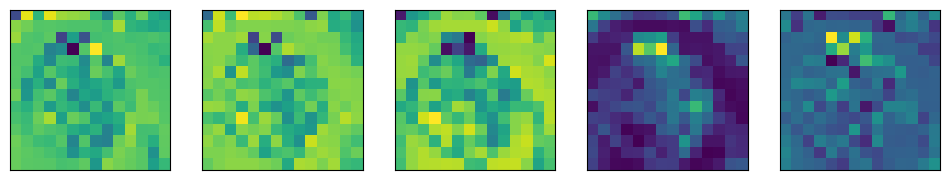

In [16]:
random_indices = random.sample(range(0, 768), k=5)
print(f"Showing random indices: {random_indices}")

fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12,12))

for i, idx in enumerate(random_indices):
    img_conv_feature_map = image_out_of_conv[:, idx, :, :]
    axs[i].imshow(img_conv_feature_map.squeeze().detach().numpy())
    axs[i].set(xticks=[], yticks=[], xticklabels=[], yticklabels=[]);


In [17]:
# Get a single feature map in tensor form
single_feature_map = image_out_of_conv[:, 0, :, :]
single_feature_map, single_feature_map.requires_grad

(tensor([[[-1.5241e-01,  1.8662e-02, -3.7617e-02,  4.1596e-02, -9.3427e-03,
           -7.4600e-03,  1.2973e-03,  6.5376e-03,  3.4347e-02, -9.0901e-02,
           -3.6037e-03, -1.6126e-02,  1.8141e-02, -4.9732e-02],
          [-1.0430e-02, -4.2262e-02, -2.0577e-02, -3.3109e-02, -2.7238e-02,
           -2.7106e-02, -2.6640e-02, -2.7192e-02, -3.4720e-02,  1.2041e-01,
            5.7421e-03, -3.8015e-02, -1.4689e-02, -5.5162e-02],
          [ 2.6420e-02, -3.3267e-02, -3.5782e-02, -2.8038e-02, -6.3726e-02,
            8.9189e-03, -1.6645e-01, -3.5477e-02, -2.5138e-02, -2.6323e-02,
           -3.5021e-02, -1.2617e-02, -5.8107e-02, -2.0629e-02],
          [-3.1741e-02, -2.9453e-02, -3.3518e-02, -1.1310e-01, -1.9394e-02,
            6.0763e-02,  5.7991e-02,  2.4372e-02, -2.4174e-02, -2.7943e-02,
           -2.6222e-02, -2.2575e-02,  3.2101e-02, -3.7142e-02],
          [-2.9857e-02, -2.7885e-02, -3.5421e-02, -4.1043e-02,  5.2951e-02,
           -1.3862e-02, -1.6381e-02, -2.3749e-03, -8.3132e-0

### 4.4 Flattening the patches using `torch.nn.Flatten()`

(Date - 4/July/2026)

In [18]:
# Current tensor shape
print(f"Current tensor shape: {image_out_of_conv.shape} -> [batch, embedding_dim, feature_map_height, feature_map_width]")

Current tensor shape: torch.Size([1, 768, 14, 14]) -> [batch, embedding_dim, feature_map_height, feature_map_width]


In [19]:
# Create flatten layer
flatten = nn.Flatten(start_dim=2, # flatten feature_map_height (dimension 2)
                     end_dim=3) # flatten feature_map_width (dimension 3)

Original image shape: torch.Size([3, 224, 224])
Image feature map shape: torch.Size([1, 768, 14, 14])
Flattened image feature map shape: torch.Size([1, 768, 196])


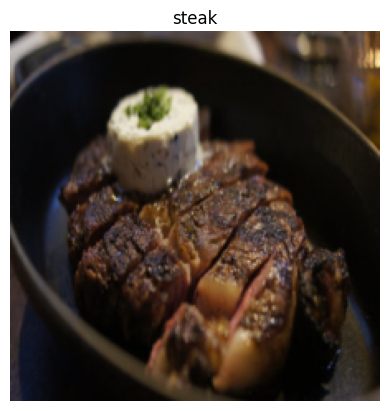

In [20]:
# 1. View single image
plt.imshow(image.permute(1, 2, 0)) # adjust for matplotlib
plt.title(class_names[label])
plt.axis(False);
print(f"Original image shape: {image.shape}")

# 2. Turn image into feature maps
image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension to avoid shape errors
print(f"Image feature map shape: {image_out_of_conv.shape}")

# 3. Flatten the feature maps
image_out_of_conv_flattened = flatten(image_out_of_conv)
print(f"Flattened image feature map shape: {image_out_of_conv_flattened.shape}")

In [21]:
# Get flattened image patch embeddings in right shape
image_out_of_conv_flattened_reshaped = image_out_of_conv_flattened.permute(0, 2, 1) # [batch_size, P^2•C, N] -> [batch_size, N, P^2•C]
print(f"Patch embedding sequence shape: {image_out_of_conv_flattened_reshaped.shape} -> [batch_size, num_patches, embedding_size]")

Patch embedding sequence shape: torch.Size([1, 196, 768]) -> [batch_size, num_patches, embedding_size]


(np.float64(-0.5), np.float64(195.5), np.float64(0.5), np.float64(-0.5))

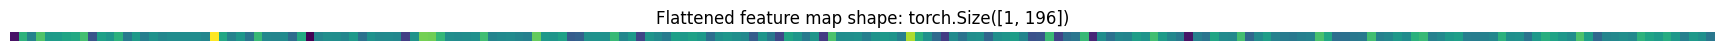

In [22]:
single_flattened_feature_map = image_out_of_conv_flattened_reshaped[:, :, 0]

plt.figure(figsize=(22,22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(f"Flattened feature map shape: {single_flattened_feature_map.shape}")
plt.axis("off")

In [23]:
# See the flattened feature map as a tensor
single_flattened_feature_map, single_flattened_feature_map.requires_grad, single_flattened_feature_map.shape

(tensor([[-1.5241e-01,  1.8662e-02, -3.7617e-02,  4.1596e-02, -9.3427e-03,
          -7.4600e-03,  1.2973e-03,  6.5376e-03,  3.4347e-02, -9.0901e-02,
          -3.6037e-03, -1.6126e-02,  1.8141e-02, -4.9732e-02, -1.0430e-02,
          -4.2262e-02, -2.0577e-02, -3.3109e-02, -2.7238e-02, -2.7106e-02,
          -2.6640e-02, -2.7192e-02, -3.4720e-02,  1.2041e-01,  5.7421e-03,
          -3.8015e-02, -1.4689e-02, -5.5162e-02,  2.6420e-02, -3.3267e-02,
          -3.5782e-02, -2.8038e-02, -6.3726e-02,  8.9189e-03, -1.6645e-01,
          -3.5477e-02, -2.5138e-02, -2.6323e-02, -3.5021e-02, -1.2617e-02,
          -5.8107e-02, -2.0629e-02, -3.1741e-02, -2.9453e-02, -3.3518e-02,
          -1.1310e-01, -1.9394e-02,  6.0763e-02,  5.7991e-02,  2.4372e-02,
          -2.4174e-02, -2.7943e-02, -2.6222e-02, -2.2575e-02,  3.2101e-02,
          -3.7142e-02, -2.9857e-02, -2.7885e-02, -3.5421e-02, -4.1043e-02,
           5.2951e-02, -1.3862e-02, -1.6381e-02, -2.3749e-03, -8.3132e-02,
          -7.6939e-02, -2

### 4.5 Putting it all together

In [24]:
class PatchEmbedding(nn.Module):
    """Turns a 2D input image into a 1D sequence learnable embedding vector.

    Args:
        in_channels (int): Number of color channels for the input images. Defaults to 3.
        patch_size (int): Size of patches to convert input image into. Defaults to 16.
        embedding_dim (int): Size of embedding to turn image into. Defaults to 768.
    """

    def __init__(self,
                 in_channels=3,
                 patch_size=16,
                 embedding_dim=768):
        super().__init__()
        
        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embedding_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size,
                                 padding=0)
        
        self.flatten = nn.Flatten(start_dim=2,
                                  end_dim=3)
        
    def forward(self, x):
        image_resolution = x.shape[-1]
        assert image_resolution % patch_size == 0, f"Image size must be divisible by patch size | Image shape: {image_resolution} | Patch size: {patch_size}"

        x_patched = self.patcher(x)
        x_flatten = self.flatten(x_patched)
        return x_flatten.permute(0,2,1)

In [25]:
set_seeds()

patchify = PatchEmbedding(in_channels=3,
                          patch_size=16,
                          embedding_dim=768)

print(f"Original shape of image: {image.unsqueeze(0).shape}")
patch_embedded_image = patchify(image.unsqueeze(0))
print(f"Image shape after going through patchify: {patch_embedded_image.shape}")

Original shape of image: torch.Size([1, 3, 224, 224])
Image shape after going through patchify: torch.Size([1, 196, 768])


In [26]:
# Create random input sizes
random_input_image = (1, 3, 224, 224)
random_input_image_error = (1, 3, 250, 250) # will error because image size is incompatible with patch_size

# Get a summary of the input and outputs of PatchEmbedding (uncomment for full output)
summary(PatchEmbedding(),
        input_size=random_input_image, # try swapping this for "random_input_image_error"
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
PatchEmbedding (PatchEmbedding)          [1, 3, 224, 224]     [1, 196, 768]        --                   True
├─Conv2d (patcher)                       [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
├─Flatten (flatten)                      [1, 768, 14, 14]     [1, 768, 196]        --                   --
Total params: 590,592
Trainable params: 590,592
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 115.76
Input size (MB): 0.60
Forward/backward pass size (MB): 1.20
Params size (MB): 2.36
Estimated Total Size (MB): 4.17

### 4.6 Creating the class token embedding

In [27]:
print(patch_embedded_image)
print(f"patch embedded image shape: {patch_embedded_image.shape}")

tensor([[[-0.6419,  0.2530, -0.2011,  ...,  0.3121, -0.0241,  0.1939],
         [-0.3971,  0.0378,  0.0111,  ...,  0.2745, -0.3247,  0.1434],
         [-0.2904,  0.0860, -0.0707,  ...,  0.2205, -0.1551,  0.0842],
         ...,
         [-0.0951, -0.0165, -0.0439,  ...,  0.0144,  0.0036,  0.0440],
         [-0.2890,  0.0858, -0.1194,  ...,  0.1862, -0.0676,  0.0536],
         [-0.2062, -0.0100, -0.1148,  ...,  0.1803, -0.0701,  0.1215]]],
       grad_fn=<PermuteBackward0>)
patch embedded image shape: torch.Size([1, 196, 768])


In [28]:
# Get the batch size and embedding dimension
batch_size = patch_embedded_image.shape[0]
embedding_dimension = patch_embedded_image.shape[-1]

# Create the class token embedding as a learnable parameter that shares the same size as the embedding dimension (D)
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension), # [batch_size, number_of_tokens, embedding_dimension]
                           requires_grad=True) # make sure the embedding is learnable

# Show the first 10 examples of the class_token
print(class_token[:, :, :10])

# Print the class_token shape
print(f"Class token shape: {class_token.shape} -> [batch_size, number_of_tokens, embedding_dimension]")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Class token shape: torch.Size([1, 1, 768]) -> [batch_size, number_of_tokens, embedding_dimension]


In [29]:
# Add the class token embedding to the front of the patch embedding
patch_embedded_image_with_class_embedding = torch.cat((class_token, patch_embedded_image),
                                                      dim=1) # concat on first dimension

# Print the sequence of patch embeddings with the prepended class token embedding
print(patch_embedded_image_with_class_embedding)
print(f"Sequence of patch embeddings with class token prepended shape: {patch_embedded_image_with_class_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.6419,  0.2530, -0.2011,  ...,  0.3121, -0.0241,  0.1939],
         [-0.3971,  0.0378,  0.0111,  ...,  0.2745, -0.3247,  0.1434],
         ...,
         [-0.0951, -0.0165, -0.0439,  ...,  0.0144,  0.0036,  0.0440],
         [-0.2890,  0.0858, -0.1194,  ...,  0.1862, -0.0676,  0.0536],
         [-0.2062, -0.0100, -0.1148,  ...,  0.1803, -0.0701,  0.1215]]],
       grad_fn=<CatBackward0>)
Sequence of patch embeddings with class token prepended shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


### 4.7 Creating the position embedding

(Date - 5/June/2026)

In [30]:
# Calculate N (number of patches)
number_of_patches = int((height * width) / patch_size**2)

# Get embedding dimension
embedding_dimension = patch_embedded_image_with_class_embedding.shape[2]

# Create the learnable 1D position embedding
position_embedding = nn.Parameter(torch.ones(1,
                                             number_of_patches+1,
                                             embedding_dimension),
                                  requires_grad=True) # make sure it's learnable

# Show the first 10 sequences and 10 position embedding values and check the shape of the position embedding
print(position_embedding[:, :10, :10])
print(f"Position embedding shape: {position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Position embedding shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [31]:
# Add the position embedding to the patch and class token embedding
patch_and_position_embedding = patch_embedded_image_with_class_embedding + position_embedding
print(patch_and_position_embedding)
print(f"Patch embeddings, class token prepended and positional embeddings added shape: {patch_and_position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[2.0000, 2.0000, 2.0000,  ..., 2.0000, 2.0000, 2.0000],
         [0.3581, 1.2530, 0.7989,  ..., 1.3121, 0.9759, 1.1939],
         [0.6029, 1.0378, 1.0111,  ..., 1.2745, 0.6753, 1.1434],
         ...,
         [0.9049, 0.9835, 0.9561,  ..., 1.0144, 1.0036, 1.0440],
         [0.7110, 1.0858, 0.8806,  ..., 1.1862, 0.9324, 1.0536],
         [0.7938, 0.9900, 0.8852,  ..., 1.1803, 0.9299, 1.1215]]],
       grad_fn=<AddBackward0>)
Patch embeddings, class token prepended and positional embeddings added shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


### 4.8 putting it all together

In [32]:
set_seeds()

# 1. Set patch size
patch_size = 16

# 2. Print shape of original image tensor and get the image dimensions
print(f"Image tensor shape: {image.shape}")
height, width = image.shape[1], image.shape[2]

# 3. Get image tensor and add batch dimension
x = image.unsqueeze(0)
print(f"Input image with batch dimension shape: {x.shape}")

# 4. Create patch embedding layer
patch_embedding_layer = PatchEmbedding(in_channels=3,
                                       patch_size=patch_size,
                                       embedding_dim=768)

# 5. Pass image through patch embedding layer
patch_embedding = patch_embedding_layer(x)
print(f"Patching embedding shape: {patch_embedding.shape}")

# 6. Create class token embedding
batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension),
                           requires_grad=True) # make sure it's learnable
print(f"Class token embedding shape: {class_token.shape}")

# 7. Prepend class token embedding to patch embedding
patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim=1)
print(f"Patch embedding with class token shape: {patch_embedding_class_token.shape}")

# 8. Create position embedding
number_of_patches = int((height * width) / patch_size**2)
position_embedding = nn.Parameter(torch.ones(1, number_of_patches+1, embedding_dimension),
                                  requires_grad=True) # make sure it's learnable

# 9. Add position embedding to patch embedding with class token
patch_and_position_embedding = patch_embedding_class_token + position_embedding
print(f"Patch and position embedding shape: {patch_and_position_embedding.shape}")

Image tensor shape: torch.Size([3, 224, 224])
Input image with batch dimension shape: torch.Size([1, 3, 224, 224])
Patching embedding shape: torch.Size([1, 196, 768])
Class token embedding shape: torch.Size([1, 1, 768])
Patch embedding with class token shape: torch.Size([1, 197, 768])
Patch and position embedding shape: torch.Size([1, 197, 768])


## 5. Equation 2: Multi-Head Attention (MSA)